In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib
import os

In [2]:
# ==========================================
# 1. 데이터 로드
# ==========================================
df = pd.read_csv('./health_data.csv', header=0)
df.columns = ['timestamp', 'avg_hr', 'rmssd', 'acc_mag']

# 숫자로 변환
df = df.apply(pd.to_numeric, errors='coerce')

# 타임스탬프 변환
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True).dt.tz_convert('Asia/Seoul')
df = df.sort_values('datetime').reset_index(drop=True)

print(f"총 데이터 수: {len(df)}개")
print(f"수집 기간: {df['datetime'].min()} ~ {df['datetime'].max()}")
print(df.head())

총 데이터 수: 650개
수집 기간: 2026-04-27 00:57:00+09:00 ~ 2026-04-27 13:14:00+09:00
       timestamp     avg_hr      rmssd   acc_mag                  datetime
0  1777219020000  78.826923   9.013617  9.970879 2026-04-27 00:57:00+09:00
1  1777219080000  87.288889   8.203724  8.225143 2026-04-27 00:58:00+09:00
2  1777219140000  90.305085   8.528723  9.591596 2026-04-27 00:59:00+09:00
3  1777219200000  93.711538   8.473115       NaN 2026-04-27 01:00:00+09:00
4  1777219260000  75.705882  12.074037  9.694043 2026-04-27 01:01:00+09:00


In [3]:
# acc_mag의 결측치 처리(이전값으로 대체)
df['acc_mag'] = df['acc_mag'].ffill()

In [4]:
df.head()

,timestamp,avg_hr,rmssd,acc_mag,datetime
0,1777219020000,78.826923,9.013617,9.970879,2026-04-27 00:57:00+09:00
1,1777219080000,87.288889,8.203724,8.225143,2026-04-27 00:58:00+09:00
2,1777219140000,90.305085,8.528723,9.591596,2026-04-27 00:59:00+09:00
3,1777219200000,93.711538,8.473115,9.591596,2026-04-27 01:00:00+09:00
4,1777219260000,75.705882,12.074037,9.694043,2026-04-27 01:01:00+09:00


In [5]:
# ==========================================
# 2. 파생변수 계산
# ==========================================

# 컬럼명 통일 (기획서 기준)
df = df.rename(columns={
    'avg_hr':  'current_hr',
    'acc_mag': 'current_acc_mag',
})

# (0) current_hrv = ln(rmssd)
df['current_hrv'] = np.log1p(df['rmssd'])  # log(1 + rmssd) → rmssd=0 방어

# (1) HR / ACC 비율 (움직임 없는데 심박 높으면 이상)
df['hr_acc_ratio'] = df['current_hr'] / (df['current_acc_mag'] + 1)

# (2) HRV 급감율 (최근 5분 평균 대비 현재 HRV 하락량)
hrv_5m_avg = df['current_hrv'].rolling(window=5, min_periods=1).mean()
df['hrv_drop_rate_5m'] = hrv_5m_avg - df['current_hrv']

# (3) 무기력 지속 시간 (current_acc_mag 낮은 상태 누적)
lethargy_threshold = 10.5  # 거의 움직임 없는 상태
df['lethargy_duration'] = (
    (df['current_acc_mag'] < lethargy_threshold)
    .astype(int)
    .rolling(window=60, min_periods=1)
    .sum()
)

# (4) 움직임 변동성 (최근 5분 분산)
df['acc_variance_5m'] = df['current_acc_mag'].rolling(window=5, min_periods=1).var().fillna(0)

# 잉여 컬럼 제거
df = df.drop(columns=['rmssd'], errors='ignore')

# 최종 피처
FEATURES = [
    'current_hr',
    'current_hrv',        # ln(rmssd)
    'current_acc_mag',
    'hr_acc_ratio',
    'hrv_drop_rate_5m',
    'lethargy_duration',
    'acc_variance_5m',
]

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype                     
---  ------             --------------  -----                     
 0   timestamp          650 non-null    int64                     
 1   current_hr         650 non-null    float64                   
 2   current_acc_mag    650 non-null    float64                   
 3   datetime           650 non-null    datetime64[ms, Asia/Seoul]
 4   current_hrv        650 non-null    float64                   
 5   hr_acc_ratio       650 non-null    float64                   
 6   hrv_drop_rate_5m   650 non-null    float64                   
 7   lethargy_duration  650 non-null    float64                   
 8   acc_variance_5m    650 non-null    float64                   
dtypes: datetime64[ms, Asia/Seoul](1), float64(7), int64(1)
memory usage: 45.8 KB


In [7]:
df.head()

,timestamp,current_hr,current_acc_mag,datetime,current_hrv,hr_acc_ratio,hrv_drop_rate_5m,lethargy_duration,acc_variance_5m
0,1777219020000,78.826923,9.970879,2026-04-27 00:57:00+09:00,2.303946,7.185106,0.000000,1.0,0.000000
1,1777219080000,87.288889,8.225143,2026-04-27 00:58:00+09:00,2.219608,9.462064,0.042169,2.0,1.523797
2,1777219140000,90.305085,9.591596,2026-04-27 00:59:00+09:00,2.254311,8.526108,0.004978,3.0,0.843107
3,1777219200000,93.711538,9.591596,2026-04-27 01:00:00+09:00,2.248458,8.847726,0.008123,4.0,0.589141
4,1777219260000,75.705882,9.694043,2026-04-27 01:01:00+09:00,2.570628,7.079257,-0.251238,5.0,0.466249


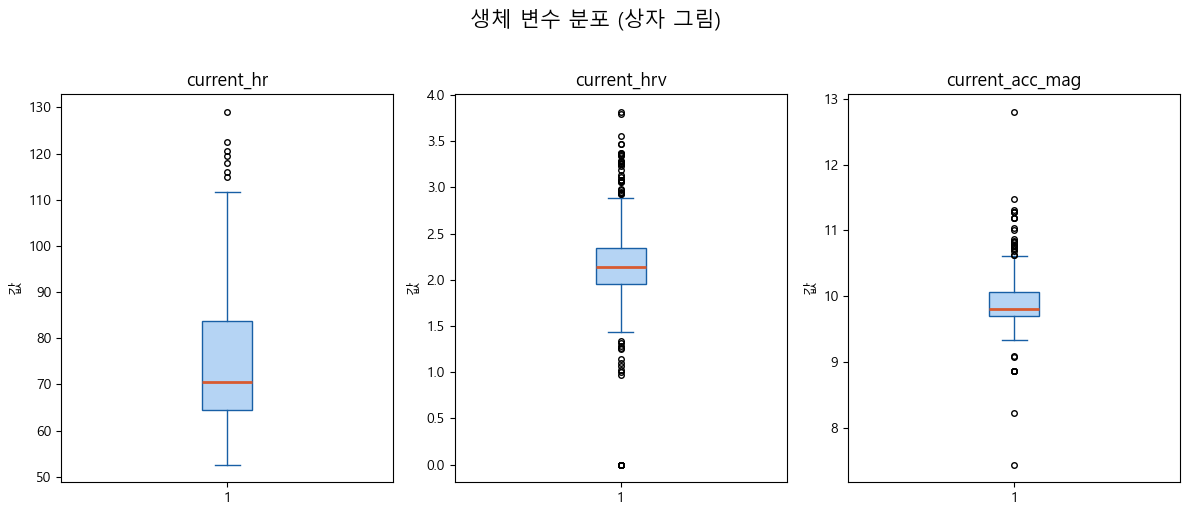

In [ ]:
# ==========================================
# 3. IQR 기반 이상치 확인
# ==========================================

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트 (Windows)
# matplotlib.rcParams['font.family'] = 'AppleGothic'  # Mac
 
FEATURES = ["current_hr", "current_hrv", "current_acc_mag"]
 
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
 
for ax, col in zip(axes, FEATURES):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
               medianprops=dict(color="#D85A30", linewidth=2),
               whiskerprops=dict(color="#185FA5"),
               capprops=dict(color="#185FA5"),
               flierprops=dict(marker="o", color="#E24B4A", markersize=4))
    ax.set_title(col, fontsize=13)
    ax.set_ylabel("값")
 
plt.suptitle("생체 변수 분포 (상자 그림)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


In [9]:
Q1 = df[FEATURES].quantile(0.25)
Q3 = df[FEATURES].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_counts = ((df[FEATURES] < lower) | (df[FEATURES] > upper)).sum()
outlier_ratio  = outlier_counts / len(df)

summary = pd.DataFrame({
    "이상치 개수": outlier_counts,
    "비율(%)": (outlier_ratio * 100).round(2),
    "하한값": lower.round(4),
    "상한값": upper.round(4),
})

print(summary)

                 이상치 개수  비율(%)      하한값       상한값
current_hr            7   1.08  35.6497  112.4727
current_hrv          55   8.46   1.3855    2.9151
current_acc_mag      34   5.23   9.1489   10.6158


In [10]:
# ==========================================
# 4. 모델 설정
# ==========================================
import pickle
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


MODEL_STORE = Path("model-store")
CONTAMINATION = 0.005

In [11]:
# ==========================================
# 5. 모델 학습
# ==========================================

def train(student_id: int, train_df: pd.DataFrame):
    X = train_df[FEATURES].fillna(train_df[FEATURES].median())
 
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
 
    model = IsolationForest(
        n_estimators=200,
        contamination=CONTAMINATION,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_scaled)
 
    save_path = MODEL_STORE / str(student_id)
    save_path.mkdir(parents=True, exist_ok=True)
    with open(save_path / "isolation_forest.pkl", "wb") as f:
        pickle.dump({"model": model, "scaler": scaler}, f)
 
    print(f"[학습 완료] student_id={student_id} | 학습 데이터 {len(train_df)}건")


In [12]:
# ==========================================
# 6. 모델 추론 
# ==========================================

def predict_batch(student_id: int, test_df: pd.DataFrame) -> pd.DataFrame:
    model_path = MODEL_STORE / str(student_id) / "isolation_forest.pkl"
    with open(model_path, "rb") as f:
        bundle = pickle.load(f)
 
    model: IsolationForest = bundle["model"]
    scaler: StandardScaler  = bundle["scaler"]
 
    X = test_df[FEATURES].fillna(test_df[FEATURES].median())
    X_scaled = scaler.transform(X)
 
    preds  = model.predict(X_scaled)           # -1 이상치 / 1 정상
    scores = model.decision_function(X_scaled) # 낮을수록 이상
 
    result_df = test_df.copy()
    result_df["anomaly_score"] = np.round(scores, 4)
    result_df["is_anomaly"]    = preds == -1
 
    return result_df

In [13]:
# ==========================================
# 7. 결과 출력
# ==========================================

def print_summary(result_df: pd.DataFrame):
    total     = len(result_df)
    anomalies = result_df["is_anomaly"].sum()

    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)

    print(f"\n[추론 결과] 총 {total}건 중 이상치 {anomalies}건 ({anomalies/total:.1%})")
    print(f"  score 범위: {result_df['anomaly_score'].min():.4f} ~ {result_df['anomaly_score'].max():.4f}")

    print("\n--- 이상치 탐지된 행 ---")
    anomaly_rows = result_df[result_df["is_anomaly"]].sort_values("anomaly_score")
    print(anomaly_rows.to_string(index=True))

In [14]:
# ==========================================
# 8. 실행
# ==========================================

STUDENT_ID = 101

# 앞 500개 학습 / 뒤 150개 추론
train_df = df.iloc[:500].reset_index(drop=True)
test_df  = df.iloc[500:].reset_index(drop=True)

print(f"학습: {len(train_df)}건 / 추론: {len(test_df)}건")

# 학습
train(STUDENT_ID, train_df)

# 추론
result_df = predict_batch(STUDENT_ID, test_df)

# 결과 출력
print_summary(result_df)

학습: 500건 / 추론: 150건
[학습 완료] student_id=101 | 학습 데이터 500건

[추론 결과] 총 150건 중 이상치 1건 (0.7%)
  score 범위: -0.0129 ~ 0.3202

--- 이상치 탐지된 행 ---
        timestamp  current_hr  current_acc_mag                  datetime  current_hrv  hr_acc_ratio  hrv_drop_rate_5m  lethargy_duration  acc_variance_5m  anomaly_score  is_anomaly
85  1777258800000       104.0         10.77775 2026-04-27 12:00:00+09:00          0.0       8.83021          1.614089               59.0         0.213071        -0.0129        True
